# Recurrent Neural Network (RNN) for Text Generation

**Name:** Pradeep Manikandan D  
**Roll Number:** `24BAD088`  

## Aim
To implement a Recurrent Neural Network (RNN) for text generation and evaluate its ability to generate meaningful text by predicting the next word in a sequence.



## PART A — Dataset Preparation

The Tiny Shakespeare dataset is loaded from Hugging Face. The text is then cleaned, tokenized, converted into integer sequences, and padded so that all training samples have the same length.

In [1]:
# PART A: Imports and student details

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Name: Pradeep Manikandan D")
print("Roll Number: YOUR_ROLL_NUMBER")
print("TensorFlow version:", tf.__version__)


Name: Pradeep Manikandan D
Roll Number: YOUR_ROLL_NUMBER
TensorFlow version: 2.20.0


In [2]:
# PART A: Load Tiny Shakespeare from Hugging Face

# This dataset configuration provides the Tiny Shakespeare text.
# If the dataset repository used by your lab changes, only DATASET_NAME
# needs to be changed.

DATASET_NAME = "Trelis/tiny-shakespeare"

dataset = load_dataset(DATASET_NAME)

print(dataset)
print("\nAvailable splits:", list(dataset.keys()))


README.md:   0%|          | 0.00/497 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/119k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/472 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/49 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

Available splits: ['train', 'test']


In [3]:
# Explore the dataset and identify the text column

split_name = list(dataset.keys())[0]
data = dataset[split_name]

print(data)
print("\nColumn names:", data.column_names)
print("\nFirst sample:")
print(data[0])


Dataset({
    features: ['Text'],
    num_rows: 472
})

Column names: ['Text']

First sample:
{'Text': "First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to th

In [ ]:
# Extract text and display a sample
TEXT_COLUMN = "text"
if TEXT_COLUMN not in data.column_names:
    # Automatically find a likely text column if the expected name is unavailable.
    text_candidates = [c for c in data.column_names if data.features[c].dtype == "string"]
    if not text_candidates:
        raise ValueError("No text column was found in the selected dataset.")
    TEXT_COLUMN = text_candidates[0]
text = "\n".join(str(x) for x in data[TEXT_COLUMN])
print("Text column:", TEXT_COLUMN)
print("Number of characters:", len(text))
print("\nFirst 1000 characters:\n")
print(text[:1000])


Text column: Text
Number of characters: 1222825

First 1000 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the

In [5]:
# Convert text to lowercase

text = text.lower()

print(text[:500])


first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [6]:
# Tokenization and vocabulary creation

tokenizer = Tokenizer(
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\\t\\n',
    lower=True,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary size:", total_words)
print("\nFirst 20 vocabulary entries:")
print(list(tokenizer.word_index.items())[:20])


Vocabulary size: 12934

First 20 vocabulary entries:
[('<OOV>', 1), ('o', 2), ('a', 3), ('i', 4), ('he', 5), ('d', 6), ('ha', 7), ('h', 8), ('e', 9), ('g', 10), ('\n', 11), ('of', 12), ('s', 13), ('his', 14), ('you', 15), ('my', 16), ('is', 17), ('me', 18), ('wi', 19), ('\na', 20)]


In [7]:
# Generate next-word prediction sequences

token_list = tokenizer.texts_to_sequences([text])[0]

# Keep the sequence length manageable for a classroom experiment.
SEQ_LENGTH = 10

input_sequences = []

for i in range(SEQ_LENGTH, len(token_list)):
    sequence = token_list[i-SEQ_LENGTH:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input shape before padding:", X.shape)
print("Target shape:", y.shape)
print("Example input:", X[0])
print("Example target:", y[0])


Input shape before padding: (280417, 10)
Target shape: (280417,)
Example input: [ 297  173  222 1059   48 1536    3   31  614   21]
Example target: 70


In [8]:
# Apply sequence padding

X = pad_sequences(
    X,
    maxlen=SEQ_LENGTH,
    padding="pre",
    truncating="pre"
)

print("Input shape after padding:", X.shape)
print("Example padded sequence:", X[0])


Input shape after padding: (280417, 10)
Example padded sequence: [ 297  173  222 1059   48 1536    3   31  614   21]


In [9]:
# Train-validation split

split_index = int(0.9 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Training input shape:", X_train.shape)
print("Validation input shape:", X_val.shape)


Training samples: 252375
Validation samples: 28042
Training input shape: (252375, 10)
Validation input shape: (28042, 10)


**Screenshot checkpoint — Part A:** Run the above cells and capture screenshots showing the student details, dataset exploration, vocabulary, sequence generation, padding, and train/validation split.

## PART B — Implementing the RNN Model

The model contains:
- An **Embedding** layer for dense word representations.
- A **SimpleRNN** layer for learning sequential dependencies.
- A **Dense + Softmax** output layer for next-word prediction.

In [10]:
# PART B: Build the Simple RNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

EMBEDDING_DIM = 64
RNN_UNITS = 128

model = Sequential([
    Embedding(input_dim=total_words, output_dim=EMBEDDING_DIM, input_length=SEQ_LENGTH),
    SimpleRNN(RNN_UNITS),
    Dense(total_words, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Screenshot checkpoint — Part B:** Capture the model summary showing the Embedding, SimpleRNN, and Dense layers.

## PART C — Training and Evaluation

The RNN is trained on the prepared sequences. Training and validation accuracy/loss are recorded and visualized against epochs.

In [11]:
# PART C: Train the RNN

EPOCHS = 10
BATCH_SIZE = 256

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 109s 109ms/step - accuracy: 0.0663 - loss: 6.3802 - val_accuracy: 0.0963 - val_loss: 6.2316
Epoch 2/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 138s 105ms/step - accuracy: 0.1434 - loss: 5.5977 - val_accuracy: 0.1358 - val_loss: 5.9533
Epoch 3/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 142s 105ms/step - accuracy: 0.1782 - loss: 5.1775 - val_accuracy: 0.1497 - val_loss: 5.9039
Epoch 4/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 150s 113ms/step - accuracy: 0.1990 - loss: 4.8784 - val_accuracy: 0.1543 - val_loss: 5.9164
Epoch 5/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 110s 111ms/step - accuracy: 0.2132 - loss: 4.6349 - val_accuracy: 0.1561 - val_loss: 5.9627
Epoch 6/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 111s 112ms/step - accuracy: 0.2274 - loss: 4.4228 - val_accuracy: 0.1551 - val_loss: 6.0436
Epoch 7/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 106s 107ms/step - accuracy: 0.2416 - loss: 4.2331 - val_accuracy: 0.1570 - val_loss: 6.1305
Epoch 8/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 110s 112ms/step - accuracy: 0.2581 -

In [12]:
# Record final training and validation metrics

final_train_accuracy = history.history["accuracy"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print(f"Training Accuracy   : {final_train_accuracy:.4f}")
print(f"Validation Accuracy : {final_val_accuracy:.4f}")
print(f"Training Loss       : {final_train_loss:.4f}")
print(f"Validation Loss     : {final_val_loss:.4f}")


Training Accuracy   : 0.2953
Validation Accuracy : 0.1525
Training Loss       : 3.7503
Validation Loss     : 6.3996


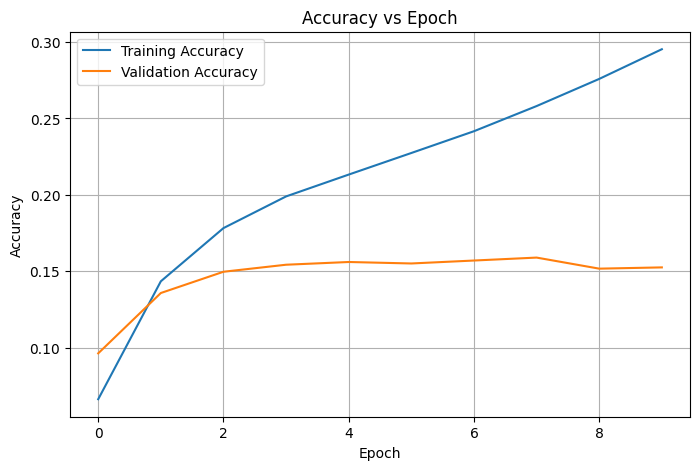

In [13]:
# Accuracy vs Epoch

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


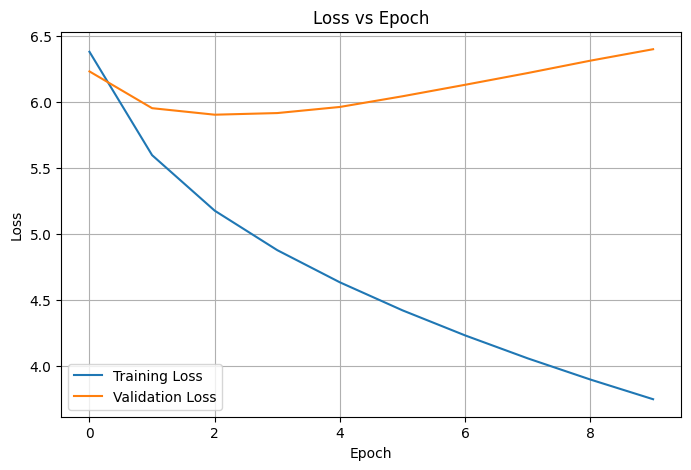

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# Summary table of final performance

print("FINAL PERFORMANCE")
print("-" * 35)
print(f"Training Accuracy   : {final_train_accuracy:.4f}")
print(f"Validation Accuracy : {final_val_accuracy:.4f}")
print(f"Training Loss       : {final_train_loss:.4f}")
print(f"Validation Loss     : {final_val_loss:.4f}")


FINAL PERFORMANCE
-----------------------------------
Training Accuracy   : 0.2953
Validation Accuracy : 0.1525
Training Loss       : 3.7503
Validation Loss     : 6.3996


**Screenshot checkpoint — Part C:** Capture the training output, final metrics, Accuracy vs Epoch graph, and Loss vs Epoch graph.

## PART D — Text Generation

The trained RNN predicts one word at a time. Each predicted word is appended to the current sequence and the process is repeated to generate a complete text sample.

In [16]:
# PART D: Reverse vocabulary for converting predicted indices into words

index_to_word = {index: word for word, index in tokenizer.word_index.items()}

def generate_text(seed_text, next_words=30, temperature=0.8):
    """Generate text using the trained RNN."""
    generated = seed_text.lower()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([generated])[0]
        token_list = pad_sequences(
            [token_list],
            maxlen=SEQ_LENGTH,
            padding="pre",
            truncating="pre"
        )

        predictions = model.predict(token_list, verbose=0)[0]

        # Temperature controls randomness.
        predictions = np.asarray(predictions).astype("float64")
        predictions = np.log(predictions + 1e-8) / temperature
        probabilities = np.exp(predictions) / np.sum(np.exp(predictions))

        predicted_id = np.random.choice(len(probabilities), p=probabilities)

        next_word = index_to_word.get(predicted_id, "")
        if not next_word or next_word == "<OOV>":
            continue

        generated += " " + next_word

    return generated


In [17]:
# Generate multiple samples using different seed inputs

seed_inputs = [
    "to be or not",
    "the king is",
    "my lord and",
    "what is the"
]

for seed in seed_inputs:
    print("=" * 80)
    print("Seed:", seed)
    print("Generated text:")
    print(generate_text(seed, next_words=30, temperature=0.8))
    print()


Seed: to be or not
Generated text:
to be or not ye i hese i s ra sform'd o him 
our words presage heed or blows o chari y 

romeo 
 o help hy body i o gueless apparel rush'd wi

Seed: the king is
Generated text:
the king is a poor fellow a d he ha dle who by he loss of mi e
ca gripe i le i his well a d i a s ra e
wi h for

Seed: my lord and
Generated text:
my lord and is a e of her a d deed 
bo h a d i for a di g ' is i mi e ha have bee 

glouces er 
 ei her

Seed: what is the
Generated text:
what is the s re ches h wi h his
fi ger a d sir i die 
 o priso a d i my gra d wherefore dos hou o ell crab 
for hou



In [18]:
# Compare generated samples

samples = {}

for seed in seed_inputs:
    samples[seed] = generate_text(seed, next_words=40, temperature=0.8)

for seed, sample in samples.items():
    print(f"Seed: {seed}")
    print(sample)
    print("\n")


Seed: to be or not
to be or not ha i may break his arm'd 
how far i have i e der for a d by ourselves 
u il his fierce ha res o me may ouch 
 o ge hy fa her a d he res 
are you


Seed: the king is
the king is bu a d all a ic 
were o her sorrow were a loa hs a d heir dug 

all 
how coulds hou murderers as hey ha k ow for wha she should say pluck your pe y 
i' he seemi


Seed: my lord and
my lord and le me live a d bei g e gla d's fa her 
reaso ha o heir eyes 
warwick as he pe i g by his 
bu is o hi g i my embassade our a bawd 

 urse 
weepi g


Seed: what is the
what is the ki g i beseech your grace
look o his majes y beheld me speak a d vic ory 
by my chamber clare ce edward are as u real o be ecessi y is o he grou d 
which ar hou wil




### Observation

The generated text should demonstrate that the RNN has learned some sequential and linguistic patterns from the Tiny Shakespeare dataset. However, a Simple RNN may produce grammatically imperfect, repetitive, or contextually inconsistent sentences, especially when the generated sequence becomes long. Different seed inputs can lead to different generated outputs because the model predicts subsequent words based on the preceding context.

**Screenshot checkpoint — Part D:** Capture the generated text for multiple seed inputs and the observations.

Finally, save the notebook and upload it to GitHub as required by the laboratory instructions.